In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
!pip install opencv-python

1. Thresholding để phân đoạn ảnh

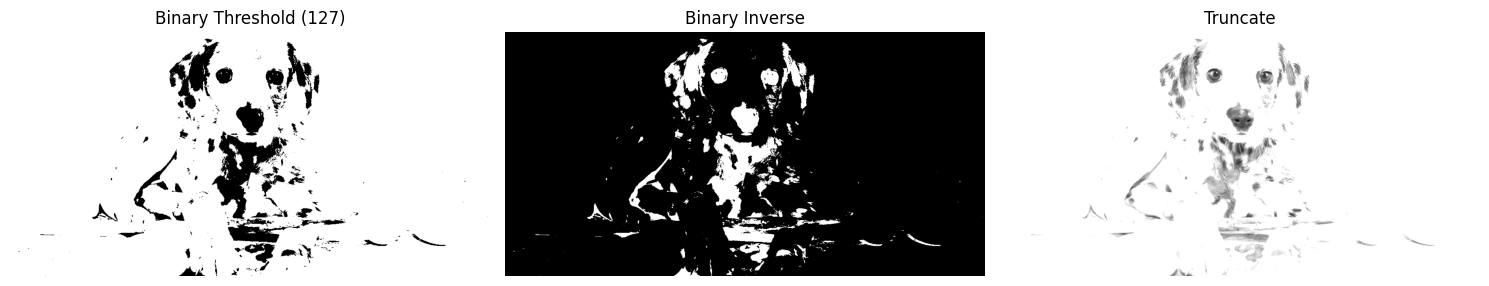

In [5]:
import cv2 as cv
import matplotlib.pyplot as plt

# Using the grayscale image 'img_gray' from the previous steps
# If 'img_gray' is not available, we assume it was loaded from /content/Picture1.jpg

# Set a global threshold value
threshold_value = 127

# Apply different types of thresholding
ret, thresh_binary = cv.threshold(img_gray, threshold_value, 255, cv.THRESH_BINARY)
ret, thresh_binary_inv = cv.threshold(img_gray, threshold_value, 255, cv.THRESH_BINARY_INV)
ret, thresh_trunc = cv.threshold(img_gray, threshold_value, 255, cv.THRESH_TRUNC)

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(thresh_binary, cmap='gray')
plt.title(f'Binary Threshold ({threshold_value})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_binary_inv, cmap='gray')
plt.title('Binary Inverse')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_trunc, cmap='gray')
plt.title('Truncate')
plt.axis('off')

plt.tight_layout()
plt.show()

2. Otsu algorithm để phân đoạn ảnh vân tay

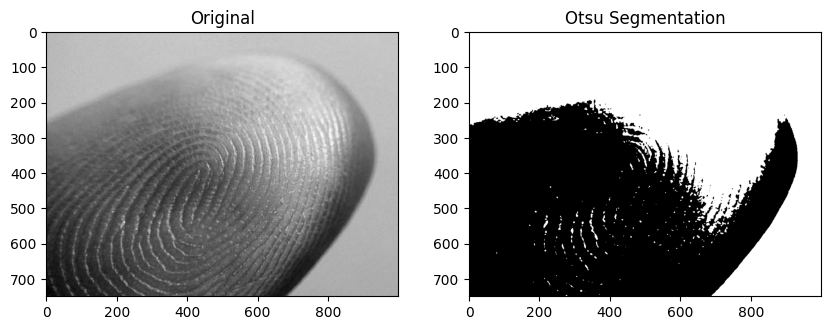

In [7]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread('/content/vantay.jpg', 0)

# Làm mịn ảnh
blur = cv2.GaussianBlur(img, (5,5), 0)

# Áp dụng Otsu
_, otsu = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Hiển thị
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Otsu Segmentation")
plt.imshow(otsu, cmap='gray')

plt.show()

3. Clustering techniques trong phân đoạn ảnh, K-mean clustering

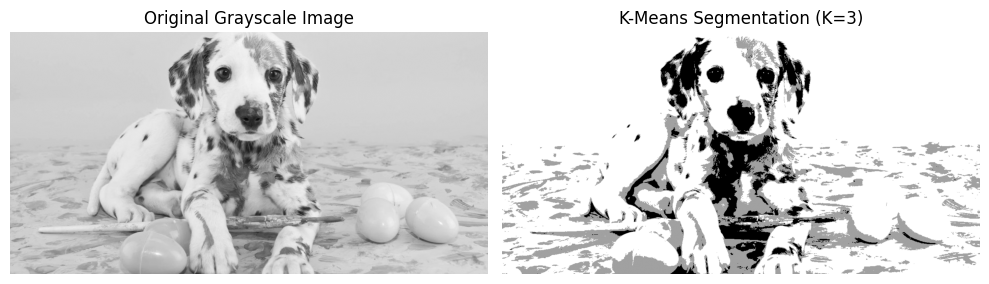

Image segmented into 3 clusters using K-Means.


In [8]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Reshape the image for K-Means
# For grayscale, we need to reshape from (height, width) to (height * width, 1)
# For color, we would reshape from (height, width, 3) to (height * width, 3)
pixel_values = img_gray.reshape((-1, 1))

# Convert to float32 for K-Means
pixel_values = np.float32(pixel_values)

# Define stopping criteria for K-Means
# (type, max_iter, epsilon) -- type is TERMINATION_CRITERIA_EPS or TERMINATION_CRITERIA_MAX_ITER or both
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Choose the number of clusters (K)
k = 3  # Example: segment into 3 intensity regions

# Apply K-Means clustering
# ret: compactness, labels: cluster index for each pixel, center: cluster centers
ret, labels, center = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Convert back to uint8 and reshape to original image dimensions
center = np.uint8(center)
segmented_image = center[labels.flatten()]
segmented_image = segmented_image.reshape(img_gray.shape)

# Display the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title(f'K-Means Segmentation (K={k})')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Image segmented into {k} clusters using K-Means.")

4. Sử dụng thuật toán Region growing

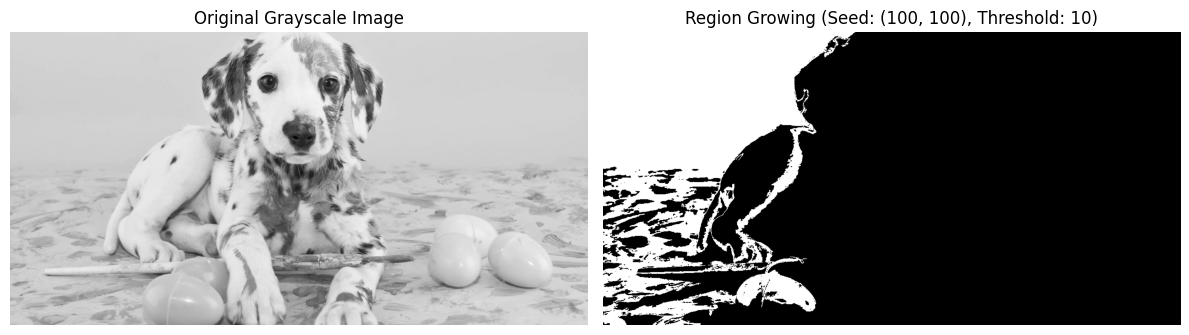

Region growing applied with seed (100, 100) and threshold 10.


In [11]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def region_growing(img, seed, threshold):
    # Get image dimensions
    h, w = img.shape

    # Initialize a blank image for the segmented region
    segmented_img = np.zeros_like(img, dtype=np.uint8)

    # Initialize a list of pixels to visit
    # Each element is a tuple (row, col)
    current_pixels = [seed]

    # Keep track of visited pixels to avoid redundant processing
    visited = np.zeros_like(img, dtype=bool)

    # Mark the seed as visited and add to the segmented image
    visited[seed[0], seed[1]] = True
    segmented_img[seed[0], seed[1]] = 255

    # Get the intensity value of the seed pixel
    seed_intensity = img[seed[0], seed[1]]

    # Define neighbors for 8-connectivity
    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 (0, -1),           (0, 1),
                 (1, -1),  (1, 0),  (1, 1)]

    # While there are pixels to visit
    while current_pixels:
        # Pop the last pixel from the list
        px, py = current_pixels.pop(0) # Using pop(0) for BFS, pop() for DFS

        # Check all 8 neighbors
        for dx, dy in neighbors:
            nx, ny = px + dx, py + dy

            # Check if the neighbor is within image bounds and not visited yet
            if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                # Mark as visited
                visited[nx, ny] = True

                # Check if the intensity difference is within the threshold
                if abs(int(img[nx, ny]) - int(seed_intensity)) <= threshold:
                    segmented_img[nx, ny] = 255  # Add to the segmented region
                    current_pixels.append((nx, ny)) # Add to list for further processing

    return segmented_img
seed_point = (100, 100) # Example seed point
intensity_threshold = 10 # Example threshold

# Perform region growing
segmented_region = region_growing(img_gray, seed_point, intensity_threshold)

# Display the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_region, cmap='gray')
plt.title(f'Region Growing (Seed: {seed_point}, Threshold: {intensity_threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Region growing applied with seed {seed_point} and threshold {intensity_threshold}.")

5. Sử dụng thuật toán Split and merge để phân đoạn ảnh

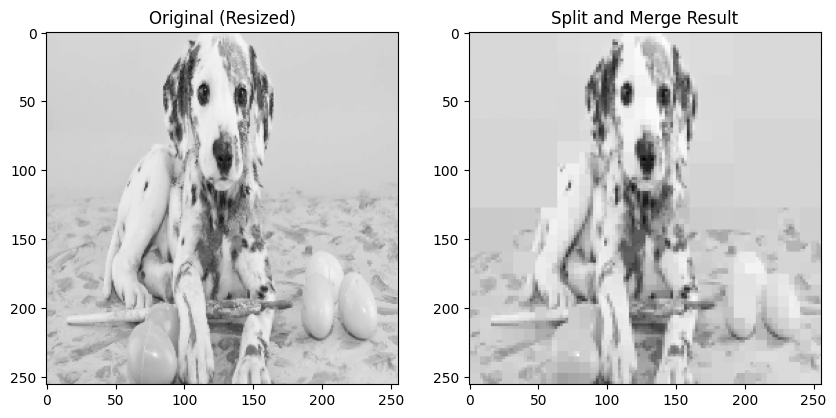

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def check_homogeneity(img, threshold):
    return np.std(img) <= threshold

def split(img, x, y, w, h, threshold):
    if check_homogeneity(img[y:y+h, x:x+w], threshold) or w <= 2 or h <= 2:
        return [((x, y, w, h), np.mean(img[y:y+h, x:x+w]))]
    else:
        w2, h2 = w // 2, h // 2
        return (split(img, x, y, w2, h2, threshold) +
                split(img, x + w2, y, w - w2, h2, threshold) +
                split(img, x, y + h2, w2, h - h2, threshold) +
                split(img, x + w2, y + h2, w - w2, h - h2, threshold))

# Tải ảnh
img_sm = cv2.imread('/content/Picture1.jpg', 0)
img_sm = cv2.resize(img_sm, (256, 256)) # Resize để chạy nhanh hơn

# Thực hiện Split
regions = split(img_sm, 0, 0, img_sm.shape[1], img_sm.shape[0], 10)

# Tạo ảnh kết quả
res_img = np.zeros_like(img_sm)
for (x, y, w, h), val in regions:
    res_img[y:y+h, x:x+w] = val

# Hiển thị
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original (Resized)")
plt.imshow(img_sm, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Split and Merge Result")
plt.imshow(res_img, cmap='gray')
plt.show()

6. Phân đoạn ảnh với Edge-based sigmentation

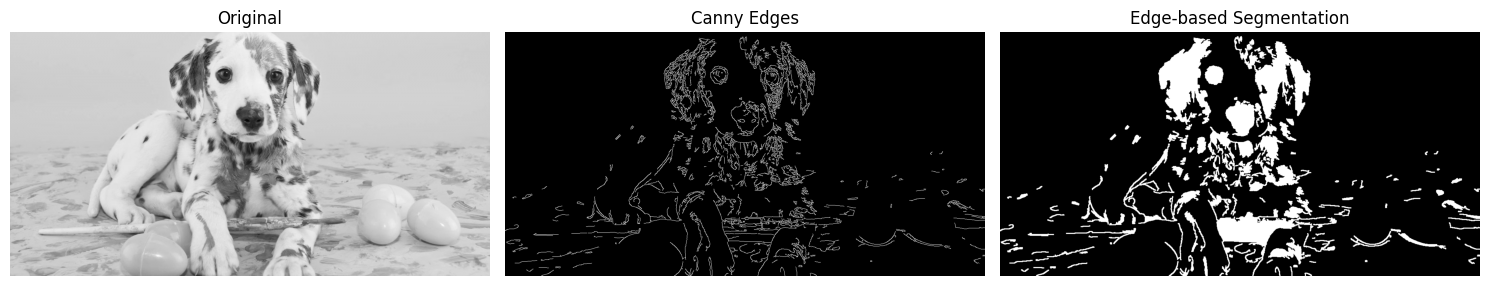

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img_edge = cv2.imread('/content/Picture1.jpg', 0)

# 1. Sử dụng Canny để tìm cạnh
edges = cv2.Canny(img_edge, 100, 200)

# 2. Giãn nở các cạnh để nối các điểm đứt gãy (Morphological Dilation)
kernel = np.ones((3,3), np.uint8)
dilated_edges = cv2.dilate(edges, kernel, iterations=1)

# 3. Làm đầy các vùng kín (Filling holes)
from scipy import ndimage
filled_mask = ndimage.binary_fill_holes(dilated_edges).astype(np.uint8) * 255

# Hiển thị kết quả
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img_edge, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Canny Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Edge-based Segmentation")
plt.imshow(filled_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()